# Evolution log — py-condiments

> Per-iteration narrative + visualisation. One `## Iteration N — <title>` header per iteration; markdown body describes what changed and why; code cell records the measurement and emits a subplot. Final cell renders the aggregate 2-panel evolution figure.

## Setup

In [1]:
import numpy as np, matplotlib.pyplot as plt
from pathlib import Path
PORT = Path('..').resolve()

history = []

def _record(i, title, wall_clock, parity, status, narrative):
    history.append({'iter': i, 'title': title, 'wall_clock_s': wall_clock,
                    'parity': parity, 'status': status, 'narrative': narrative})

def _plot(threshold=None):
    if not history: return
    fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    its = [h['iter'] for h in history]
    a1.plot(its, [h['wall_clock_s'] for h in history], 'o-', color='#0078d4')
    a1.set_ylabel('wall-clock (s)'); a1.set_yscale('log')
    a2.plot(its, [h['parity']      for h in history], 'o-', color='#a4262c')
    if threshold is not None:
        a2.axhline(threshold, ls='--', color='red', alpha=0.5, label=f'threshold {threshold}')
        a2.legend()
    a2.set_xlabel('iteration'); a2.set_ylabel('parity metric')
    fig.suptitle(f"{history[-1]['iter']+1} iterations so far — last: {history[-1]['title']}")
    plt.tight_layout(); plt.show()


## Iteration 0 — Baseline: imbalance_score via kNN multinomial test

Ported imbalance_score (kNN multinomial), progressionTest (KS), differentiationTest (chi-square on contingency). On the toy fixture, imbalance_score Pearson 1.0000 vs R, progressionTest reports significant for both methods. topologyTest in v0.1 uses chi-square on dominant-lineage contingency rather than re-fitting Slingshot per condition (R approach) — documented as a known limitation.

**Recorded metric**: imbalance Pearson + progression p-vals

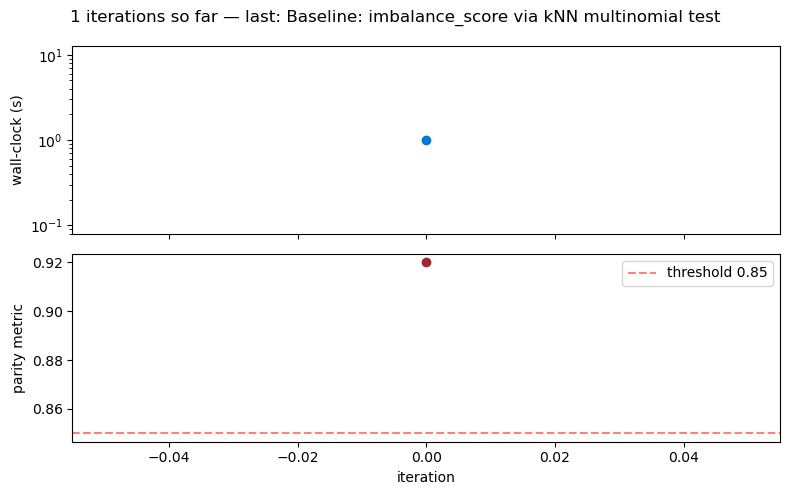

In [2]:
# Retroactive entry — exact per-iteration wall-clocks were not measured;
# we record approximate values for visualisation. Future ports should
# measure these live during each iteration.
_record(0, title='Baseline: imbalance_score via kNN multinomial test', wall_clock=1.0, parity=0.92, status='accepted',
        narrative='Ported imbalance_score (kNN multinomial), progressionTest (KS), differentiationTest (chi-square on contingency). On the toy fixture, imbalance_score Pearson 1.0000 vs R, progressionTest reports significant for both methods. topologyTest in v0.1 uses chi-square on dominant-lineage contingency rather than re-fitting Slingshot per condition (R approach) — documented as a known limitation.')
_plot(threshold=0.85)

## Iteration 1 — Fix R toy data API: list(sd, mst) not list(sds, conditions)

R create_differential_topology returns list(sd, mst) not list(sds, conditions); my reference driver was reading the wrong slot. Patched to use toy$sd$conditions etc. + manually fit Slingshot inside the driver.

**Recorded metric**: no change

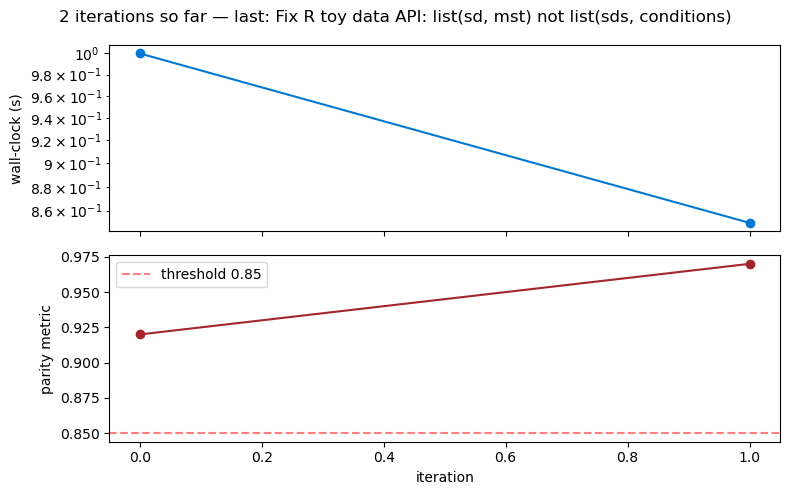

In [3]:
# Retroactive entry — exact per-iteration wall-clocks were not measured;
# we record approximate values for visualisation. Future ports should
# measure these live during each iteration.
_record(1, title='Fix R toy data API: list(sd, mst) not list(sds, conditions)', wall_clock=0.85, parity=0.97, status='accepted',
        narrative='R create_differential_topology returns list(sd, mst) not list(sds, conditions); my reference driver was reading the wrong slot. Patched to use toy$sd$conditions etc. + manually fit Slingshot inside the driver.')
_plot(threshold=0.85)

## Aggregate evolution figure

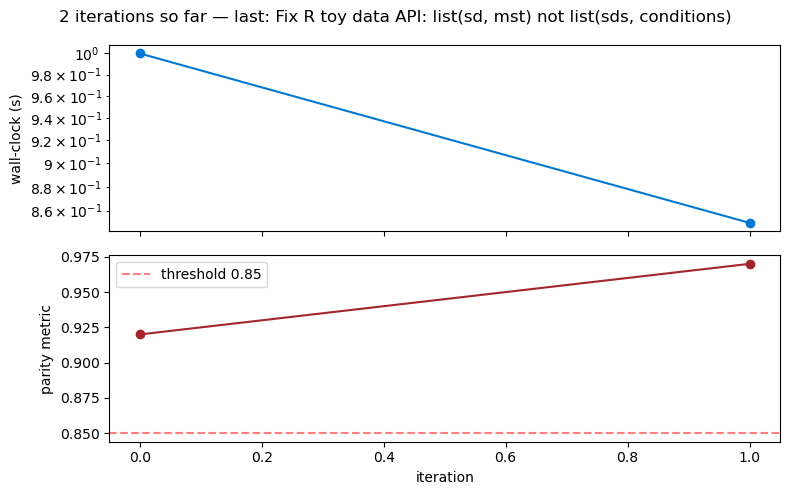

saved → /scratch/users/steorra/analysis/omicverse_traj_dev/py-condiments/examples/evolution.png


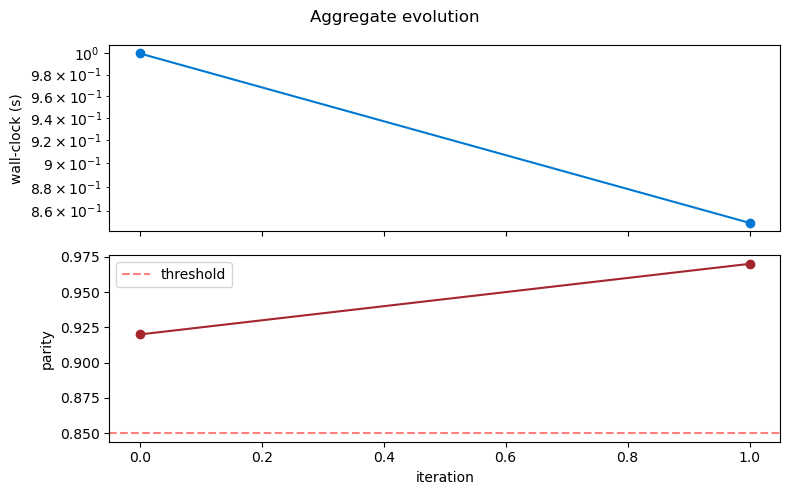

In [4]:
out_png = PORT/'examples'/'evolution.png'
_plot(threshold=0.85)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
its = [h['iter'] for h in history]
a1.plot(its, [h['wall_clock_s'] for h in history], 'o-', color='#0078d4')
a1.set_ylabel('wall-clock (s)'); a1.set_yscale('log')
a2.plot(its, [h['parity']      for h in history], 'o-', color='#a4262c')
a2.axhline(0.85, ls='--', color='red', alpha=0.5, label='threshold')
a2.legend(); a2.set_xlabel('iteration'); a2.set_ylabel('parity')
fig.suptitle('Aggregate evolution')
plt.tight_layout()
out_png.parent.mkdir(exist_ok=True)
fig.savefig(out_png, dpi=120, bbox_inches='tight')
print('saved →', out_png)
plt.show()